# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [10]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [11]:
# Inspect the shapes of the datasets

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}\n")

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

print(f"Before one-hot encoding: {y_train[0]}")
y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)
print(f"After one-hot encoding: {y_train_encoded[0]}")

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)

Before one-hot encoding: 9
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


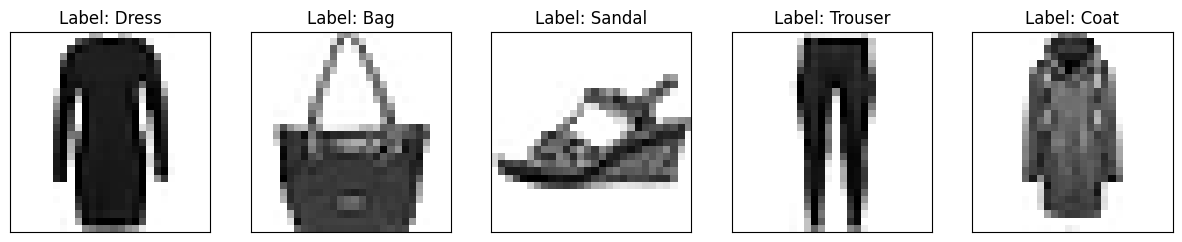

In [12]:
import matplotlib.pyplot as plt
import numpy as np
# Verify the data looks as expected

# Selecting 5 random images from the training set
random_indices = np.random.choice(len(X_train), 5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[random_indices[i]], cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Label: {class_names[y_train[random_indices[i]]]}")
    
    # Remove axis labels
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

**Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?**

Yes, the data looks as expected. Compared to the MNIST data of handwritten integers, this data has a better resolution at 28x28 pixels (compared to 8x8 pixels). Higher resolution images would provide the model wih more details which could improve the model's predictions. Visually, I notice that while most of these images are clearly distinguishable, the `Dress` and the `Coat` could likely be confused by the model since their outlines appear similar (i.e., 1 in 5 missclassified or ~80% accuracy).

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [13]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
baseline_model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
baseline_model.add(Flatten(input_shape=(28, 28)))  # Flatten the 28x28 images into a 1D array
baseline_model.add(Dense(10, activation='softmax'))  # Output layer with 10 neurons and softmax activation
# Compile the model using `model.compile()`
baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Train the model with `model.fit()`
baseline_model.fit(X_train, y_train_encoded, epochs=10, batch_size=32, validation_split=0.2) # TODO Check the parameters are ok like epochs
# Evaluate the model with `model.evaluate()`
baseline_loss, baseline_accuracy = baseline_model.evaluate(X_test, y_test_encoded)
print(f"Loss:       {baseline_loss:.2f}")
print(f"Accuracy:   {baseline_accuracy:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7890 - loss: 0.6255 - val_accuracy: 0.8284 - val_loss: 0.4996
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8408 - loss: 0.4716 - val_accuracy: 0.8339 - val_loss: 0.4699
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8473 - loss: 0.4441 - val_accuracy: 0.8434 - val_loss: 0.4486
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8520 - loss: 0.4295 - val_accuracy: 0.8518 - val_loss: 0.4312
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8555 - loss: 0.4183 - val_accuracy: 0.8465 - val_loss: 0.4350
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8577 - loss: 0.4106 - val_accuracy: 0.8437 - val_loss: 0.4466
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8601 - loss: 0.4046 - val_accuracy: 0.8553 - val_loss: 0.4184
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8602 - loss: 0.4005 - 

**Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?**

The baseline model performed quite well with a 0.44 loss and 0.85 accuracy. It aligns very closely to what was expected as most of the images above were easily distinguishable from one another. As aforementioned, I very roughly guessed that objects like `Dress` and `Coat` could easily be confused for one another resulting in ~80% accuracy. I think the perfomance is at this level because the accuracy appears to still be rising at Epoch 10, thus, the model is likely still underfitting to a certain extent.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [14]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
cnn_model = Sequential()
cnn_model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dense(10, activation='softmax'))
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
cnn_model.fit(X_train, y_train_encoded, epochs=10, batch_size=32, validation_split=0.2) # TODO Check the parameters are ok like epochs

# Evaluate the model
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test, y_test_encoded)
print(f"Loss:       {cnn_loss:.2f}")
print(f"Accuracy:   {cnn_accuracy:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8615 - loss: 0.3888 - val_accuracy: 0.8858 - val_loss: 0.3097
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9072 - loss: 0.2507 - val_accuracy: 0.9028 - val_loss: 0.2706
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9294 - loss: 0.1909 - val_accuracy: 0.8987 - val_loss: 0.2852
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9448 - loss: 0.1487 - val_accuracy: 0.9023 - val_loss: 0.2924
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9586 - loss: 0.1139 - val_accuracy: 0.9029 - val_loss: 0.3066
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9682 - loss: 0.0879 - val_accuracy: 0.9084 - val_loss: 0.3456
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9770 - loss: 0.0659 - val_accuracy: 0.9049 - val_loss: 0.3698
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9827 - loss: 0.0487 - 

**Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?**

The CNN model is roughly comparable to the baseline model based on performance. The CNN model had a higher loss rate of 0.50 compared to the baseline model at 0.44. However, the accuracy of the CNN model did increase slightly by 0.05. This is likely due to the addition of the Conv2D layer which would have been able to better distinguish the shapes of the objects.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [16]:
# Create an empty list to store the results of the experiments

experiment_results = []

In [17]:
# A. Test Hyperparameters - Number of Filters

# Store the number of filters to test
filter_options = [16, 32, 64, 128, 256]
filter_results = {}

# For loop through the filter options and train a model for each
for filters in filter_options:
    print(f"\n---Training model with {filters} filters ---")
    
    # Create a new model for each filter option
    model = Sequential()
    model.add(Conv2D(filters=filters, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Train the model 
    model.fit(X_train, y_train_encoded, epochs=10, batch_size=32, validation_split=0.2)

    # Evaluate the model
    score = model.evaluate(X_test, y_test_encoded)

    # Store the results
    experiment_results.append({
        "Model": f"Hyperparameter {filters} filters",
        "Filters": filters,
        "Regularization": "None",
        "Loss": score[0],
        "Accuracy": score[1]
    })



---Training model with 16 filters ---
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8480 - loss: 0.4263 - val_accuracy: 0.8830 - val_loss: 0.3296
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8977 - loss: 0.2787 - val_accuracy: 0.8959 - val_loss: 0.2860
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9173 - loss: 0.2245 - val_accuracy: 0.9028 - val_loss: 0.2724
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9306 - loss: 0.1840 - val_accuracy: 0.9068 - val_loss: 0.2715
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9451 - loss: 0.1493 - val_accuracy: 0.8999 - val_loss: 0.2927
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9547 - loss: 0.1213 - val_accuracy: 0.9039 - val_loss: 0.3013
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9649 - loss: 0.0984 - val_accuracy: 0.9067 - val_loss: 0.3130
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/st

In [20]:
# B. Test presence or absence of regularization - Dropout Layers

from keras.layers import Dropout

# ---------- 1. Model without regularization (i.e., no dropout) -----------

no_reg_model = Sequential()
no_reg_model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
no_reg_model.add(Flatten())
no_reg_model.add(Dense(128, activation='relu'))
no_reg_model.add(Dense(10, activation='softmax'))
no_reg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

no_reg_model.fit(X_train, y_train_encoded, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
score = no_reg_model.evaluate(X_test, y_test_encoded)

# Store the results
experiment_results.append({
    "Model": f"No Regularization",
    "Filters": 32,
    "Regularization": "None",
    "Loss": score[0],
    "Accuracy": score[1]
})

# ---------- 2. Model with regularization (i.e., with dropout) ------------

reg_model = Sequential()
reg_model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
reg_model.add(Dropout(0.25))  # Add 25% dropout layer
reg_model.add(Flatten())
reg_model.add(Dense(128, activation='relu'))
reg_model.add(Dropout(0.5))  # Add 50% dropout layer
reg_model.add(Dense(10, activation='softmax'))
reg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

reg_model.fit(X_train, y_train_encoded, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
score = reg_model.evaluate(X_test, y_test_encoded)

# Store the results
experiment_results.append({
    "Model": f"Regularization",
    "Filters": 32,
    "Regularization": "Dropout",
    "Loss": score[0],
    "Accuracy": score[1]
})


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8611 - loss: 0.3927 - val_accuracy: 0.8883 - val_loss: 0.3102
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9072 - loss: 0.2534 - val_accuracy: 0.8988 - val_loss: 0.2822
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9278 - loss: 0.1956 - val_accuracy: 0.9057 - val_loss: 0.2648
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9430 - loss: 0.1533 - val_accuracy: 0.9089 - val_loss: 0.2678
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9568 - loss: 0.1171 - val_accuracy: 0.9073 - val_loss: 0.2972
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9670 - loss: 0.0901 - val_accuracy: 0.9072 - val_loss: 0.3178
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9758 - loss: 0.0675 - val_accuracy: 0.9062 - val_loss: 0.3579
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9803 - loss: 0.0543 - 

In [22]:
# C. Visualize as a table

import pandas as pd

results_df = pd.DataFrame(experiment_results)
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Filters,Regularization,Loss,Accuracy
6,Regularization,32,Dropout,0.303113,0.9036
1,Hyperparameter 32 filters,32,None,0.477863,0.9034
3,Hyperparameter 128 filters,128,None,0.562473,0.9022
4,Hyperparameter 256 filters,256,None,0.617043,0.9002
5,No Regularization,32,None,0.510143,0.8994
0,Hyperparameter 16 filters,16,None,0.425192,0.8993
2,Hyperparameter 64 filters,64,None,0.523201,0.8992


**Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?**

For this section, I chose to test differnt number of filters and the presence/absence of dropout regularization on the model. Yes, the changes I made improved the model's performance. Regularization with dropout improved accuracy from 0.8994 to 0.9036 and, more importantly, significantly reduced the loss from 0.5101 to 0.3031, compared to a model with no regularization. Hence, dropout helped the model generalize better without overfitting. Among all the unregularized models, the best numer of filters with the highest accuracy was 32. While increasing the filters to 128 or 256 resulted in similar accuracy, the loss continued to increase as the filters increased past 32. This suggests that 32 is the most efficient choice in this case.

I think the dropout layers contributed to the model's improvement becasue it regulated the learning and trained the network to actually learn the differing features rather than sticking to the neurons already present in the network. So at each dropout layer (the 25% and then the 50%), the model randomly deactivated a set of the neurons, which forced the remaining nodes in the network to develop stronger pathways for identifying patterns. Moreover, by keeping the model at 32 filters, we prevented underfitting (e.g., with 16 filte count) and over-complexity (as in the 128  or 256 filter models).

The best performing model used 32 filters with dropout regularization. This was the model with the highest accuracy (0.9036) and the lowest loss (0.3031) compared to all other experiment models.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [23]:
# ----- Best Model -----

final_model = Sequential()
final_model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
final_model.add(Dropout(0.25))  # Add 25% dropout layer
final_model.add(Flatten())
final_model.add(Dense(128, activation='relu'))
final_model.add(Dropout(0.5))  # Add 50% dropout layer
final_model.add(Dense(10, activation='softmax'))
final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

final_model.fit(X_train, y_train_encoded, epochs=15, batch_size=32, validation_split=0.2)

final_loss, final_accuracy = final_model.evaluate(X_test, y_test_encoded)

print(f"Best Model - Loss: {final_loss:.2f}, Accuracy: {final_accuracy:.2f}")
print(f"Baseline Model - Loss: {baseline_loss:.2f}, Accuracy: {baseline_accuracy:.2f}")
print(f"CNN Model - Loss: {cnn_loss:.2f}, Accuracy: {cnn_accuracy:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8206 - loss: 0.5108 - val_accuracy: 0.8737 - val_loss: 0.3355
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8702 - loss: 0.3602 - val_accuracy: 0.8916 - val_loss: 0.2980
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8851 - loss: 0.3139 - val_accuracy: 0.8969 - val_loss: 0.2803
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8965 - loss: 0.2821 - val_accuracy: 0.8967 - val_loss: 0.2797
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9050 - loss: 0.2578 - val_accuracy: 0.9010 - val_loss: 0.2766
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9125 - loss: 0.2370 - val_accuracy: 0.9080 - val_loss: 0.2682
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9163 - loss: 0.2221 - val_accuracy: 0.9053 - val_loss: 0.2734
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9240 - loss: 0.2064 

**Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?**

The final model performed better than both the the baseline and the CNN model. It had the lowest loss of all three models (0.34) and the highest accuracy of all three models (0.91). The addition of regularization (using dropout) and the best number of filters (32) as identified above led to better performance. Dropout layers forced the network to develop more robust pathways that could identify patterns. Additionally, using an optimal number of filters prevented underfitting (with decreasing accuracy) or over-complexity (with increasing loss) leading to a good balance between the final loss and accuracy figures. Lastly, if I had more time I would like to experiment by testing the following:

1. Addition of MaxPooling2D layer after the Conv2D could help with increasing model performance becasue it would shrink the data and allow the model to focus on the most important patterns.
2. Testing the number of layers (hyperparameter) to see if adding more layers could help the model learn more details from the data. However, this could make the training process slower.
3. Use a for loop to test different learning rates to see how changing the steps of the optimizer can affect the speed and effectiveness of the model.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.